In [3]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from PIL import Image

from config import SEED

## Carga de datos

In [1]:
def load_image_dataset(img_dir, target_size=None):
    df = pd.read_csv(os.path.join(img_dir, 'labels.csv'))
    X, y = [], []
    for _, row in df.iterrows():
        path = os.path.join(img_dir, row['filename'])
        img = Image.open(path)
        
        if target_size:
            img = img.resize(target_size, Image.BICUBIC)
        
        img = np.array(img)

        X.append(img)
        y.append(row['label'])

    return np.array(X), np.array(y)

In [2]:
dataset = 'crudos'

# Datos originales

## Imagenes

In [4]:
train_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/train_imgs'
val_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/val_imgs'
test_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/test_imgs'

In [5]:
X_train, y_train = load_image_dataset(train_dir, target_size=(372, 128))
X_val, y_val = load_image_dataset(val_dir, target_size=(372, 128))
X_test, y_test = load_image_dataset(test_dir, target_size=(372, 128))

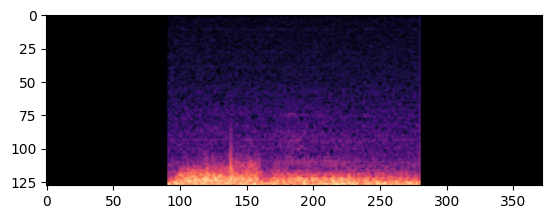

In [6]:
plt.imshow(X_train[2]);

### Transfer Learning

In [7]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(128, 372, 3))
traslation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED) # augmentacion
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = traslation_layer(x) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_7948\184640210.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [8]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
lr_schedule = keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=1e-3,
    decay_steps=3000,
    end_learning_rate=1e-7,
    power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 120s 890ms/step - auc: 0.6238 - loss: 0.6784 - recall: 0.5620 - val_auc: 0.6781 - val_loss: 0.6530 - val_recall: 0.6304
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 108s 829ms/step - auc: 0.6651 - loss: 0.6520 - recall: 0.6021 - val_auc: 0.7126 - val_loss: 0.6820 - val_recall: 0.9387
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 102s 788ms/step - auc: 0.6951 - loss: 0.6349 - recall: 0.6387 - val_auc: 0.7257 - val_loss: 0.6207 - val_recall: 0.6858
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 109s 842ms/step - auc: 0.7131 - loss: 0.6182 - recall: 0.6787 - val_auc: 0.7253 - val_loss: 0.6295 - val_recall: 0.4328
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 108s 825ms/step - auc: 0.7164 - loss: 0.6184 - recall: 0.6125 - val_auc: 0.7251 - val_loss: 0.6227 - val_recall: 0.4941
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 114s 875ms/step - auc: 0.7347 - loss: 0.6035 - recall: 0.6836 - val_auc: 0.7361 - val_loss: 0.6049 - val_recall: 0.6146
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 

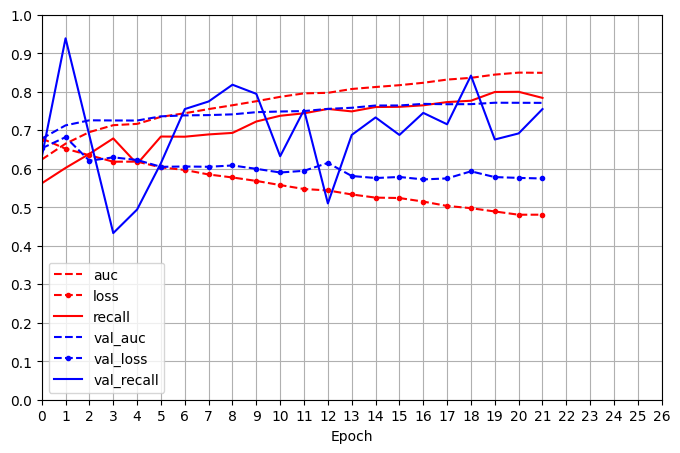

In [12]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 26], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 27), yticks=np.arange(0, 1.1, 0.1))
plt.show()

In [13]:
model.evaluate(X_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 515ms/step - auc: 0.7755 - loss: 0.5717 - recall: 0.7678


[0.5716593861579895, 0.7755248546600342, 0.7677724957466125]

### Fine-Tunning

In [14]:
# Descongelar solo las últimas capas (desde el bloque 13)
base_model.trainable = True

set_trainable = False
for layer in base_model.layers:
    if layer.name == "block_13_expand":  # desde acá para abajo, entrenable
        set_trainable = True
    layer.trainable = set_trainable

In [15]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 3,291,332 (12.56 MB)

 Trainable params: 2,025,793 (7.73 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 688,899 (2.63 MB)

In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # learning rate bajo
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()],
)

In [17]:
early_stop_fine = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [18]:
history_fine_tunning = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[early_stop_fine])

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - auc_1: 0.6263 - loss: 1.2783 - recall_1: 0.2318 - val_auc_1: 0.7174 - val_loss: 1.5951 - val_recall_1: 0.0514
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - auc_1: 0.7059 - loss: 0.6376 - recall_1: 0.6545 - val_auc_1: 0.7018 - val_loss: 1.6810 - val_recall_1: 0.0514
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - auc_1: 0.7378 - loss: 0.6072 - recall_1: 0.6733 - val_auc_1: 0.7041 - val_loss: 1.5792 - val_recall_1: 0.0593
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - auc_1: 0.7530 - loss: 0.5875 - recall_1: 0.6703 - val_auc_1: 0.7155 - val_loss: 1.3529 - val_recall_1: 0.0830
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - auc_1: 0.7709 - loss: 0.5728 - recall_1: 0.7059 - val_auc_1: 0.7151 - val_loss: 1.3106 - val_recall_1: 0.0988
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - auc_1: 0.7922 - loss: 0.5528 - recall_1: 0.7192 - val_auc_1: 0.7301 - val_loss: 1.0972 - val_recall_1: 0.1818
Epoch 7/50

In [19]:
model.evaluate(X_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 466ms/step - auc_1: 0.8048 - loss: 0.5708 - recall_1: 0.7615


[0.5708121061325073, 0.804835319519043, 0.76145339012146]

In [20]:
model.save(f'./neural_network/modelos/{dataset}_fine_tuned.keras')

## Arrays

In [21]:
train_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

val_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/val_melspectrogram.npz')
X_val = val_data['X']
y_val = val_data['y']

test_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [ ]:
X_train = X_train.reshape(-1, 128, 372, 1)
X_val = X_val.reshape(-1, 128, 372, 1)
X_test = X_test.reshape(-1, 128, 372, 1)

In [25]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

### Transfer Learning

In [36]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(128, 372, 3))
translation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED)
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED)
scale_layer = keras.layers.Rescaling(scale=2/80, offset=1)

x = flip_layer(inputs)
x = translation_layer(x)
x = scale_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model_melspec = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_7948\585285572.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [37]:
model_melspec.summary(show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_1        │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_8 (Rescaling)     │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
lr_schedule = keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=1e-3,
    decay_steps=3000,
    end_learning_rate=1e-7,
    power=1.0)

model_melspec.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [39]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [40]:
history_melspec = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 96s 692ms/step - auc_2: 0.5892 - loss: 0.6996 - recall_2: 0.5358 - val_auc_2: 0.6645 - val_loss: 0.6683 - val_recall_2: 0.8597
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 89s 683ms/step - auc_2: 0.6521 - loss: 0.6590 - recall_2: 0.6243 - val_auc_2: 0.6859 - val_loss: 0.6425 - val_recall_2: 0.5277
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 91s 700ms/step - auc_2: 0.6695 - loss: 0.6490 - recall_2: 0.6110 - val_auc_2: 0.6988 - val_loss: 0.6428 - val_recall_2: 0.6265
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 91s 697ms/step - auc_2: 0.6947 - loss: 0.6332 - recall_2: 0.6431 - val_auc_2: 0.7054 - val_loss: 0.6346 - val_recall_2: 0.4743
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 87s 667ms/step - auc_2: 0.7193 - loss: 0.6180 - recall_2: 0.6683 - val_auc_2: 0.7215 - val_loss: 0.6210 - val_recall_2: 0.7767
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 86s 659ms/step - auc_2: 0.7327 - loss: 0.6051 - recall_2: 0.6851 - val_auc_2: 0.7188 - val_loss: 0.6212 - val_recall_2: 0.705

In [41]:
model_melspec.evaluate(X_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 27s 669ms/step - auc_2: 0.7442 - loss: 0.6056 - recall_2: 0.7694


[0.6055987477302551, 0.744208037853241, 0.7693523168563843]

### Fine Tunning

In [42]:
# Descongelar solo las últimas capas (desde el bloque 13)
base_model.trainable = True

set_trainable = False
for layer in base_model.layers:
    if layer.name == "block_13_expand":  # desde acá para abajo, entrenable
        set_trainable = True
    layer.trainable = set_trainable

In [45]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # learning rate bajo
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()],
)

In [ ]:
early_stop_fine = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    min_delta=0.001
)

In [49]:
history_melspec_fine_tunning = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_fine]
    )

Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - auc_4: 0.7510 - loss: 0.5921 - recall_4: 0.7237 - val_auc_4: 0.7475 - val_loss: 0.5892 - val_recall_4: 0.7431
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - auc_4: 0.7773 - loss: 0.5670 - recall_4: 0.7657 - val_auc_4: 0.7410 - val_loss: 0.5964 - val_recall_4: 0.7411
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 184s 1s/step - auc_4: 0.7952 - loss: 0.5472 - recall_4: 0.7696 - val_auc_4: 0.7396 - val_loss: 0.5992 - val_recall_4: 0.6680
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - auc_4: 0.8116 - loss: 0.5276 - recall_4: 0.7800 - val_auc_4: 0.7348 - val_loss: 0.6090 - val_recall_4: 0.6680
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - auc_4: 0.8245 - loss: 0.5099 - recall_4: 0.7860 - val_auc_4: 0.7359 - val_loss: 0.6233 - val_recall_4: 0.5850


In [50]:
model_melspec.evaluate(X_test, y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 535ms/step - auc_4: 0.7129 - loss: 0.6272 - recall_4: 0.7346


[0.6271740794181824, 0.7129115462303162, 0.7345971465110779]

In [51]:
model_melspec.save(f'./neural_network/modelos/{dataset}_melspec.keras')

# Datos aumentados

## Imagenes

In [27]:
train_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/train_aug_imgs'
val_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/val_aug_imgs'
test_dir = f'./dataset/ciclos_procesados/{dataset}/cnn/test_aug_imgs'

In [28]:
X_train, y_train = load_image_dataset(train_dir, target_size=(372, 128))
X_val, y_val = load_image_dataset(val_dir, target_size=(372, 128))
X_test, y_test = load_image_dataset(test_dir, target_size=(372, 128))

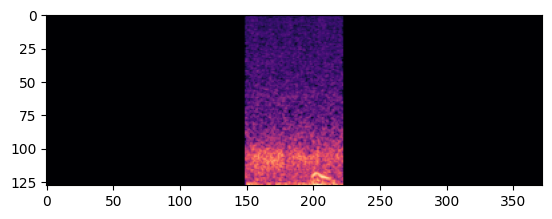

In [39]:
plt.imshow(X_train[2]);

### Transfer Learning

In [40]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(128, 372, 3))
traslation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED) # augmentacion
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = traslation_layer(x) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_13868\184640210.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [41]:
model.summary(show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_1        │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [42]:
lr_schedule = keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=1e-3,
    decay_steps=3000,
    end_learning_rate=1e-7,
    power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [43]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [44]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 370s 950ms/step - auc_2: 0.5639 - loss: 0.6955 - recall_2: 0.5150 - val_auc_2: 0.6056 - val_loss: 0.6759 - val_recall_2: 0.4850
Epoch 2/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 354s 942ms/step - auc_2: 0.5983 - loss: 0.6774 - recall_2: 0.5765 - val_auc_2: 0.6133 - val_loss: 0.6724 - val_recall_2: 0.5157
Epoch 3/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 380s 937ms/step - auc_2: 0.6232 - loss: 0.6681 - recall_2: 0.5912 - val_auc_2: 0.6276 - val_loss: 0.6697 - val_recall_2: 0.4152
Epoch 4/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 375s 919ms/step - auc_2: 0.6356 - loss: 0.6627 - recall_2: 0.6405 - val_auc_2: 0.6421 - val_loss: 0.6687 - val_recall_2: 0.3420
Epoch 5/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 389s 936ms/step - auc_2: 0.6454 - loss: 0.6572 - recall_2: 0.6401 - val_auc_2: 0.6456 - val_loss: 0.6576 - val_recall_2: 0.6389
Epoch 6/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 280s 745ms/step - auc_2: 0.6556 - loss: 0.6515 - recall_2: 0.6370 - val_auc_2: 0.6470 - val_loss: 0.6584 - val_recall_2:

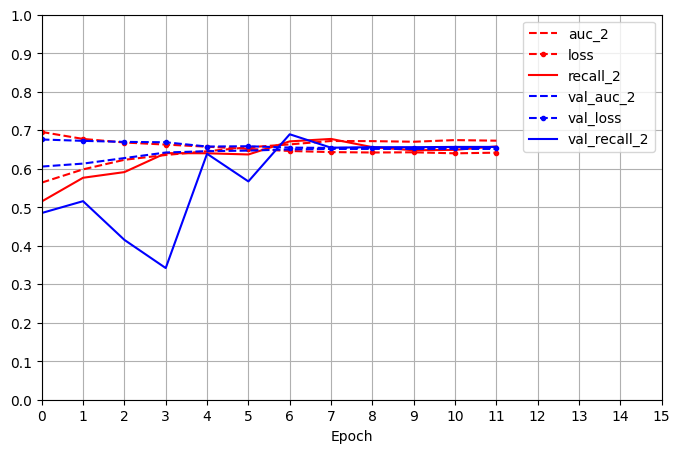

In [46]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 15], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 16), yticks=np.arange(0, 1.1, 0.1))
plt.show()

In [47]:
model.evaluate(X_test, y_test)

114/114 ━━━━━━━━━━━━━━━━━━━━ 61s 533ms/step - auc_2: 0.6438 - loss: 0.6606 - recall_2: 0.6486


[0.6606336832046509, 0.6438436508178711, 0.6485568881034851]

In [48]:
model.save(f'./neural_network/modelos/{dataset}_aug.keras')

### Fine-Tunning

In [49]:
# Descongelar solo las últimas capas (desde el bloque 13)
base_model.trainable = True

set_trainable = False
for layer in base_model.layers:
    if layer.name == "block_13_expand":  # desde acá para abajo, entrenable
        set_trainable = True
    layer.trainable = set_trainable

In [50]:
model.summary(show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_1        │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   Y   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 3,291,332 (12.56 MB)

 Trainable params: 2,025,793 (7.73 MB)

 Non-trainable params: 576,640 (2.20 MB)

 Optimizer params: 688,899 (2.63 MB)

In [51]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # learning rate bajo
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()],
)

In [52]:
early_stop_fine = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    min_delta=0.001
)

In [53]:
history_fine_tunning = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[early_stop_fine])

Epoch 1/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - auc_3: 0.5820 - loss: 0.7689 - recall_3: 0.3291 - val_auc_3: 0.6235 - val_loss: 0.8323 - val_recall_3: 0.0992
Epoch 2/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - auc_3: 0.6388 - loss: 0.6586 - recall_3: 0.6203 - val_auc_3: 0.6343 - val_loss: 0.7046 - val_recall_3: 0.2620
Epoch 3/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 440s 1s/step - auc_3: 0.6635 - loss: 0.6478 - recall_3: 0.6505 - val_auc_3: 0.6506 - val_loss: 0.6557 - val_recall_3: 0.5759
Epoch 4/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 432s 1s/step - auc_3: 0.6891 - loss: 0.6325 - recall_3: 0.6476 - val_auc_3: 0.6638 - val_loss: 0.6507 - val_recall_3: 0.5445
Epoch 5/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 461s 1s/step - auc_3: 0.6987 - loss: 0.6239 - recall_3: 0.6786 - val_auc_3: 0.6738 - val_loss: 0.6406 - val_recall_3: 0.6163
Epoch 6/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 457s 1s/step - auc_3: 0.7095 - loss: 0.6180 - recall_3: 0.6808 - val_auc_3: 0.6768 - val_loss: 0.6396 - val_recall_3: 0.5622
Epoch 7/50

In [54]:
model.evaluate(X_test, y_test)

114/114 ━━━━━━━━━━━━━━━━━━━━ 72s 631ms/step - auc_3: 0.6894 - loss: 0.6481 - recall_3: 0.5563


[0.6480517983436584, 0.6893541812896729, 0.5563101172447205]

In [ ]:
model.save(f'./neural_network/modelos/{dataset}_aug_fine_tuned.keras')

## Arrays

In [4]:
train_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/train_melspectrogram_aug.npz')
X_train = train_data['X']
y_train = train_data['y']

val_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/val_melspectrogram_aug.npz')
X_val = val_data['X']
y_val = val_data['y']

test_data = np.load(f'./dataset/ciclos_procesados/{dataset}/cnn/test_melspectrogram_aug.npz')
X_test = test_data['X']
y_test = test_data['y']

In [5]:
X_train = X_train.reshape(-1, 128, 372, 1)
X_val = X_val.reshape(-1, 128, 372, 1)
X_test = X_test.reshape(-1, 128, 372, 1)

In [6]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

### Transfer Learning

In [12]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(128, 372, 3))
translation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED)
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED)
scale_layer = keras.layers.Rescaling(scale=2/80, offset=1)

x = flip_layer(inputs)
x = translation_layer(x)
x = scale_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model_melspec = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_23536\182398130.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [13]:
model_melspec.summary(show_trainable=True)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_3 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_1 (RandomFlip)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_1        │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_1 (Rescaling)     │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_1  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_2 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_4 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_3 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_5 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
lr_schedule = keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=1e-3,
    decay_steps=9000,
    end_learning_rate=1e-7,
    power=1.0)

model_melspec.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [15]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [16]:
history_melspec = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 390s 993ms/step - auc_1: 0.5678 - loss: 0.6906 - recall_1: 0.5170 - val_auc_1: 0.5858 - val_loss: 0.6887 - val_recall_1: 0.2257
Epoch 2/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 361s 962ms/step - auc_1: 0.5847 - loss: 0.6802 - recall_1: 0.5755 - val_auc_1: 0.6080 - val_loss: 0.6838 - val_recall_1: 0.9131
Epoch 3/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 334s 889ms/step - auc_1: 0.6067 - loss: 0.6734 - recall_1: 0.5934 - val_auc_1: 0.6247 - val_loss: 0.6762 - val_recall_1: 0.8140
Epoch 4/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 374s 869ms/step - auc_1: 0.6183 - loss: 0.6698 - recall_1: 0.6047 - val_auc_1: 0.6349 - val_loss: 0.6724 - val_recall_1: 0.8523
Epoch 5/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 271s 720ms/step - auc_1: 0.6266 - loss: 0.6640 - recall_1: 0.6143 - val_auc_1: 0.6376 - val_loss: 0.6621 - val_recall_1: 0.6963
Epoch 6/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 320s 852ms/step - auc_1: 0.6366 - loss: 0.6591 - recall_1: 0.6570 - val_auc_1: 0.6406 - val_loss: 0.6591 - val_recall_1:

In [17]:
model_melspec.evaluate(X_test, y_test)

114/114 ━━━━━━━━━━━━━━━━━━━━ 57s 502ms/step - auc_1: 0.6336 - loss: 0.6735 - recall_1: 0.5574


[0.673522412776947, 0.6335840821266174, 0.5574420094490051]

In [18]:
model_melspec.save(f'./neural_network/modelos/{dataset}_melspec_aug.keras')

### Fine Tunning

In [19]:
# Descongelar solo las últimas capas (desde el bloque 13)
base_model.trainable = True

set_trainable = False
for layer in base_model.layers:
    if layer.name == "block_13_expand":  # desde acá para abajo, entrenable
        set_trainable = True
    layer.trainable = set_trainable

In [20]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # learning rate bajo
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()],
)

In [ ]:
early_stop_fine = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [22]:
history_melspec_fine_tunning = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_fine]
    )

Epoch 1/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 361s 927ms/step - auc_2: 0.5766 - loss: 0.7530 - recall_2: 0.5912 - val_auc_2: 0.6466 - val_loss: 0.6876 - val_recall_2: 0.3311
Epoch 2/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 337s 896ms/step - auc_2: 0.6233 - loss: 0.6696 - recall_2: 0.6738 - val_auc_2: 0.6428 - val_loss: 0.6586 - val_recall_2: 0.5246
Epoch 3/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 333s 884ms/step - auc_2: 0.6462 - loss: 0.6547 - recall_2: 0.6589 - val_auc_2: 0.6468 - val_loss: 0.6560 - val_recall_2: 0.5068
Epoch 4/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 335s 890ms/step - auc_2: 0.6618 - loss: 0.6452 - recall_2: 0.6724 - val_auc_2: 0.6458 - val_loss: 0.6557 - val_recall_2: 0.5848
Epoch 5/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 331s 880ms/step - auc_2: 0.6784 - loss: 0.6332 - recall_2: 0.6876 - val_auc_2: 0.6603 - val_loss: 0.6486 - val_recall_2: 0.6902
Epoch 6/50
376/376 ━━━━━━━━━━━━━━━━━━━━ 335s 892ms/step - auc_2: 0.6891 - loss: 0.6277 - recall_2: 0.6935 - val_auc_2: 0.6709 - val_loss: 0.6416 - val_recall_2:

In [23]:
model_melspec.evaluate(X_test, y_test)

114/114 ━━━━━━━━━━━━━━━━━━━━ 58s 511ms/step - auc_2: 0.6538 - loss: 0.7022 - recall_2: 0.5467


[0.702208936214447, 0.653840959072113, 0.5466893315315247]

In [24]:
model_melspec.save(f'./neural_network/modelos/{dataset}_melspec_aug_fine_tuned.keras')